In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

df = pd.read_csv("../data/car_price.csv")   
 

In [2]:


#valeurs manquants
print("Valeurs manquantes par colonne")
print(df.isnull().sum())  
  
# (imputation par la médiane pour les numériques
if df["year"].isna().sum() > 0:
    median_year = df["year"].median()
    df["year"] = df["year"].fillna(median_year)
    
if df["km_driven"].isna().sum() > 0:
    median_kmDriven= df["km_driven"].median()
    df["km_driven"]=df["km_driven"].fillna(median_kmDriven)
    
#imputation par le mode pour les catégoriques).
if df["fuel"].isna().sum()>0:
    modFuel=df["fuel"].mode()[0]
    df["fuel"]=df["fuel"].fillna(modFuel)


if df["seller_type"].isnull().sum() > 0:
    mode_seller_type = df["seller_type"].mode()[0]
    df["seller_type"] = df["seller_type"].fillna(mode_seller_type)

if df["owner"].isnull().sum() > 0:
    mode_owner = df["owner"].mode()[0]
    df["owner"] = df["owner"].fillna(mode_owner)   

# verifier si remplis
print("Valeurs manquantes après traitement :")
print(df.isnull().sum())    

#RECHERCHE DOUBLONS
print("voici le nombre des doublons dans columns")
print(df.duplicated().sum())
#supprimer les doublons
df=df.drop_duplicates()
 #verifier si dropped
print("voici le nombre des doublons apres drop")
print(df.duplicated().sum())


# DIMENSIONS FINALES
print("Dimensions finales du dataset :")
print(df.shape)


Valeurs manquantes par colonne
name               0
year              43
selling_price      0
km_driven        173
fuel              86
seller_type       65
transmission       0
owner             86
dtype: int64
Valeurs manquantes après traitement :
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64
voici le nombre des doublons dans columns
668
voici le nombre des doublons apres drop
0
Dimensions finales du dataset :
(3672, 8)


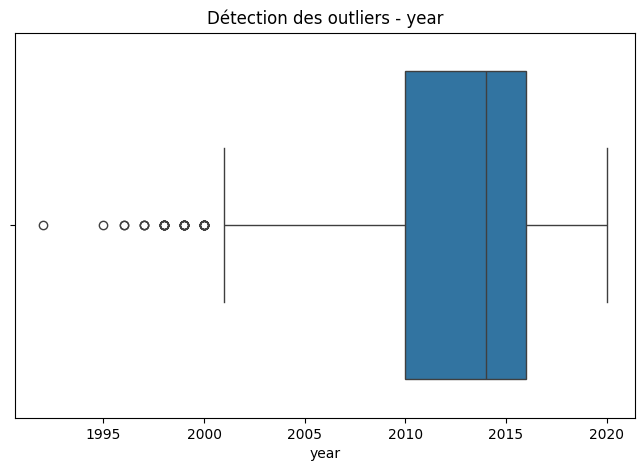


Colonne : year
Q1 : 2010.0
Q3 : 2016.0
IQR : 6.0
Limite inférieure : 2001.0
Limite supérieure : 2025.0
Nombre d'outliers : 37

Colonne : km_driven
Q1 : 38975.0
Q3 : 90000.0
IQR : 51025.0
Limite inférieure : -37562.5
Limite supérieure : 166537.5
Nombre d'outliers : 117

Colonne : selling_price
Q1 : 200000.0
Q3 : 600000.0
IQR : 400000.0
Limite inférieure : -400000.0
Limite supérieure : 1200000.0
Nombre d'outliers : 174


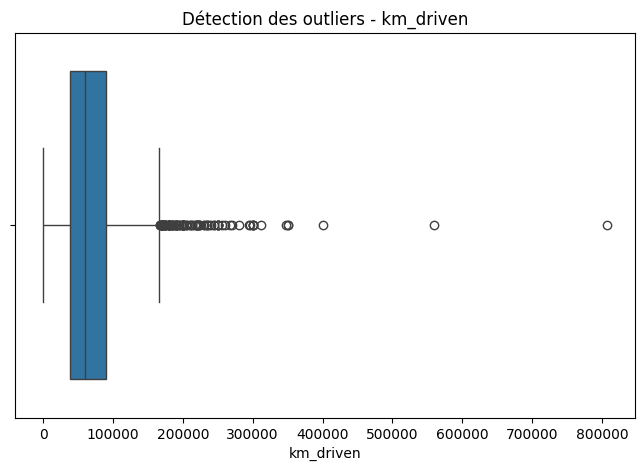


Colonne : year
Q1 : 2010.0
Q3 : 2016.0
IQR : 6.0
Limite inférieure : 2001.0
Limite supérieure : 2025.0
Nombre d'outliers : 37

Colonne : km_driven
Q1 : 38975.0
Q3 : 90000.0
IQR : 51025.0
Limite inférieure : -37562.5
Limite supérieure : 166537.5
Nombre d'outliers : 117

Colonne : selling_price
Q1 : 200000.0
Q3 : 600000.0
IQR : 400000.0
Limite inférieure : -400000.0
Limite supérieure : 1200000.0
Nombre d'outliers : 174


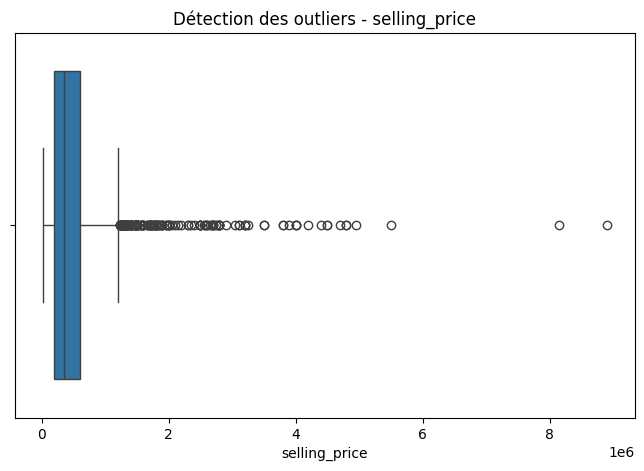


Colonne : year
Q1 : 2010.0
Q3 : 2016.0
IQR : 6.0
Limite inférieure : 2001.0
Limite supérieure : 2025.0
Nombre d'outliers : 37

Colonne : km_driven
Q1 : 38975.0
Q3 : 90000.0
IQR : 51025.0
Limite inférieure : -37562.5
Limite supérieure : 166537.5
Nombre d'outliers : 117

Colonne : selling_price
Q1 : 200000.0
Q3 : 600000.0
IQR : 400000.0
Limite inférieure : -400000.0
Limite supérieure : 1200000.0
Nombre d'outliers : 174
Outliers du prix :
                                                name    year  km_driven  \
12                   Toyota Corolla Altis 1.8 VL CVT  2018.0    25000.0   
29                        Jaguar XF 2.2 Litre Luxury  2014.0    28000.0   
30              Mercedes-Benz New C-Class 220 CDI AT  2013.0    59000.0   
35                   Audi A6 2.0 TDI  Design Edition  2013.0    50000.0   
36    Mercedes-Benz New C-Class C 220 CDI Avantgarde  2012.0    33800.0   
...                                              ...     ...        ...   
4200          Ford Ecosport 1.5 Di

In [3]:

#detections des outliers avec iqr

numeric_columns = ["year", "km_driven", "selling_price"]

for column in numeric_columns:
    
    plt.figure(figsize=(8, 5))
    
    sns.boxplot(x=df[column])
    
    plt.title(f"Détection des outliers - {column}")
    plt.xlabel(column)
    
    plt.show()
    
    #calcul de limit avec Iqr
    for column in numeric_columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
    
        IQR = Q3 - Q1
    
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
    
        outliers = df[
          (df[column] < lower_bound) |
          (df[column] > upper_bound)
        ]
    
        print("\nColonne :", column)
        print("Q1 :", Q1)
        print("Q3 :", Q3)
        print("IQR :", IQR)
        print("Limite inférieure :", lower_bound)
        print("Limite supérieure :", upper_bound)
        print("Nombre d'outliers :", len(outliers))
# Afficher les outliers du prix

Q1_price = df["selling_price"].quantile(0.25)
Q3_price = df["selling_price"].quantile(0.75)

IQR_price = Q3_price - Q1_price

lower_price = Q1_price - 1.5 * IQR_price
upper_price = Q3_price + 1.5 * IQR_price

outliers_price = df[(df["selling_price"] < lower_price) |(df["selling_price"] > upper_price)]

print("Outliers du prix :")
print(outliers_price[
    ["name", "year", "km_driven", "selling_price"]
])
# Afficher les outliers du kilométrage

Q1_km = df["km_driven"].quantile(0.25)
Q3_km = df["km_driven"].quantile(0.75)

IQR_km = Q3_km - Q1_km

lower_km = Q1_km - 1.5 * IQR_km
upper_km = Q3_km + 1.5 * IQR_km

outliers_km = df[(df["km_driven"] < lower_km) |(df["km_driven"] > upper_km)]

print("Outliers du kilométrage :")
print(outliers_km[["name", "year", "km_driven", "selling_price"]])

# supprimer column name

print("Nombre de valeurs uniques dans name :")
print(df["name"].nunique())

df = df.drop(columns=["name"])

print("Colonnes après suppression de name :")
print(df.columns)


X = df.drop(columns=["selling_price"])

y = df["selling_price"]

print("Variables X :")
print(X.columns)

print("\nVariable cible y :")
print(y.name)

# TRAIN / TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Taille X_train :", X_train.shape)
print("Taille X_test :", X_test.shape)
print("Taille y_train :", y_train.shape)
print("Taille y_test :", y_test.shape)


# TYPES DE VARIABLES

numeric_features = [
    "year",
    "km_driven"
]

categorical_features = [
    "fuel",
    "seller_type",
    "transmission",
    "owner"
]

# PREPROCESSING

numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


print("Dimensions finales du dataset :")
print(df.shape)

print("\nValeurs manquantes :")
print(df.isnull().sum())

print("\nDoublons :")
print(df.duplicated().sum())

print("\nX_train :", X_train.shape)
print("X_test :", X_test.shape)

print("\nColonnes numériques :")
print(numeric_features)

print("\nColonnes catégorielles :")
print(categorical_features)

# ==============================
# 12. SAUVEGARDE DU DATASET NETTOYÉ
# ==============================

df.to_csv("../data/clean_car_price.csv", index=False)

print("Dataset nettoyé sauvegardé avec succès.")